## Well log data processing

In [84]:
## Dados teste

In [54]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.signal import savgol_filter

In [36]:
rmn = pd.read_csv('data/rmn.csv', sep=r"\s+")
rmn.head()

,0,1,2,3,4,5,6,7,8,9,...,2192,2193,2194,2195,2196,2197,2198,2199,2200,y
0,0.808799,0.761493,0.806187,0.720554,0.721984,0.798494,0.783868,0.703372,0.737759,0.677632,...,0.000000,0.000000,0.004560,0.000000,0.000000,0.035802,0.018477,0.000000,0.056427,0.29
1,0.806849,0.772156,0.768037,0.742568,0.799492,0.779938,0.764711,0.784916,0.762178,0.670400,...,0.000000,0.002427,0.053201,0.026355,0.020801,0.000000,0.000000,0.000000,0.047609,0.30
2,0.730200,0.792758,0.776700,0.751078,0.723305,0.771900,0.695950,0.648201,0.691083,0.829490,...,0.060112,0.009801,0.018689,0.000000,0.062865,0.000000,0.000000,0.018137,0.000000,0.11
3,0.821097,0.739546,0.792519,0.851488,0.745911,0.847673,0.716392,0.636217,0.679300,0.668268,...,0.011161,0.022608,0.005721,0.012794,0.006062,0.000000,0.000000,0.025047,0.000000,0.61
4,0.735200,0.767431,0.896211,0.784622,0.787818,0.702942,0.768785,0.679844,0.784000,0.699596,...,0.000000,0.002610,0.000000,0.000000,0.017710,0.000000,0.009772,0.000000,0.008674,0.74


In [37]:
import numpy as np

# Reprodutibilidade
np.random.seed(42)

# Ruído na última casa decimal
noise = np.random.uniform(
    low=-5e-5,
    high=5e-5,
    size=rmn.shape
)

df = rmn + noise

In [38]:
df = df.iloc[:, :2000]

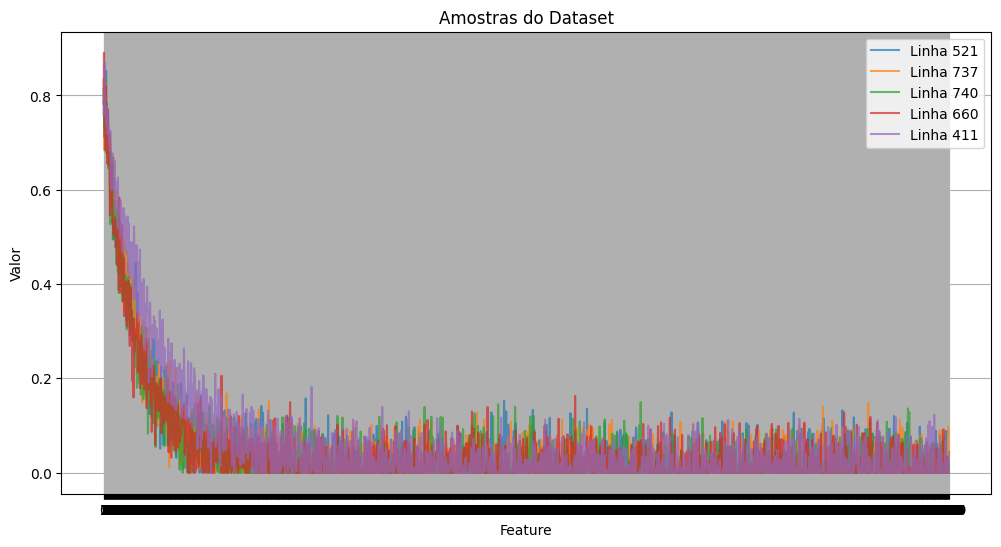

In [39]:
# Seleciona 10 linhas aleatórias
np.random.seed(42)
idx = np.random.choice(df.index, size=5, replace=False)
plt.figure(figsize=(12, 6))
for i in idx:
    plt.plot(df.columns, df.loc[i], alpha=0.7, label=f"Linha {i}")
plt.xlabel("Feature")
plt.ylabel("Valor")
plt.title("Amostras do Dataset")
plt.grid(True)
plt.legend()
plt.show()

### Gulf Coast dataset

In [72]:
rmn_2 = pd.read_csv('data/GulfCoast_RMN_Synthetic.csv')
rmn_2

,Echo_1,Echo_2,Echo_3,Echo_4,Echo_5,Echo_6,Echo_7,Echo_8,Echo_9,Echo_10,...,Echo_2992,Echo_2993,Echo_2994,Echo_2995,Echo_2996,Echo_2997,Echo_2998,Echo_2999,Echo_3000,Swirr_PHIX
0,4.528407,4.609529,4.319662,4.212327,3.781724,4.221828,3.945483,3.997451,4.446850,3.758089,...,-0.295444,0.215462,-0.104729,0.045311,0.020243,0.149533,0.152417,0.152017,0.211876,0.656594
1,4.918701,4.832363,4.252674,3.643964,4.683183,4.310226,4.121523,4.372570,4.280865,3.761923,...,0.065470,0.182019,-0.155984,0.300049,-0.079460,-0.221020,0.275079,0.180194,0.253010,0.705920
2,4.494873,4.533198,4.776482,4.094704,4.248397,4.093314,4.373367,4.466301,4.172891,3.992030,...,0.015974,0.598182,-0.139468,0.070574,0.440332,0.157131,0.181840,-0.167980,-0.128476,0.743156
3,4.294402,4.854807,4.219976,4.439989,3.969429,4.560321,4.332779,4.122140,4.088818,4.032554,...,-0.137859,-0.235864,-0.301629,0.467695,0.144521,0.382595,-0.463082,0.760449,0.179026,0.677602
4,4.934008,3.854815,3.879226,4.118688,4.321660,4.123171,4.060934,3.854166,3.933851,3.995426,...,0.143421,-0.306651,0.116346,-0.045125,0.661589,0.222024,0.062787,0.477116,0.556970,0.621254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570,3.986086,4.087141,3.464351,3.799566,3.687505,3.570083,3.509047,3.583773,3.285916,3.548128,...,0.189658,0.476490,0.860039,0.593946,0.141430,0.014020,-0.302515,-0.035068,-0.251230,0.455738
571,4.528536,3.775483,4.567504,4.032977,3.666367,3.963028,4.046457,4.021308,3.841678,4.492169,...,-0.025792,0.048097,-0.233797,-0.134929,0.338988,-0.535077,-0.249584,-0.014592,-0.130255,0.603281
572,6.129235,5.569541,6.001038,5.390358,5.342373,4.779215,5.409179,5.249593,5.554937,4.996759,...,-0.111639,-0.020529,0.448213,-0.202096,0.082706,0.358862,0.305333,-0.539753,-0.078306,0.761814
573,6.620872,5.690521,6.398179,6.067753,5.381519,5.645518,5.311704,5.762161,5.910363,5.627253,...,0.401051,0.055519,0.230203,0.264945,-0.063446,0.530108,0.116405,-0.105762,-0.113485,0.823391


In [73]:
import seaborn as sns

# Configurações de estilo para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14

In [74]:
# Exibindo as primeiras linhas e informações básicas
display(rmn_2.head())
print("\nInformações do Dataset:")
display(rmn_2.info())

print("\nValores nulos no dataset:", rmn_2.isnull().sum().sum())

,Echo_1,Echo_2,Echo_3,Echo_4,Echo_5,Echo_6,Echo_7,Echo_8,Echo_9,Echo_10,...,Echo_2992,Echo_2993,Echo_2994,Echo_2995,Echo_2996,Echo_2997,Echo_2998,Echo_2999,Echo_3000,Swirr_PHIX
0,4.528407,4.609529,4.319662,4.212327,3.781724,4.221828,3.945483,3.997451,4.446850,3.758089,...,-0.295444,0.215462,-0.104729,0.045311,0.020243,0.149533,0.152417,0.152017,0.211876,0.656594
1,4.918701,4.832363,4.252674,3.643964,4.683183,4.310226,4.121523,4.372570,4.280865,3.761923,...,0.065470,0.182019,-0.155984,0.300049,-0.079460,-0.221020,0.275079,0.180194,0.253010,0.705920
2,4.494873,4.533198,4.776482,4.094704,4.248397,4.093314,4.373367,4.466301,4.172891,3.992030,...,0.015974,0.598182,-0.139468,0.070574,0.440332,0.157131,0.181840,-0.167980,-0.128476,0.743156
3,4.294402,4.854807,4.219976,4.439989,3.969429,4.560321,4.332779,4.122140,4.088818,4.032554,...,-0.137859,-0.235864,-0.301629,0.467695,0.144521,0.382595,-0.463082,0.760449,0.179026,0.677602
4,4.934008,3.854815,3.879226,4.118688,4.321660,4.123171,4.060934,3.854166,3.933851,3.995426,...,0.143421,-0.306651,0.116346,-0.045125,0.661589,0.222024,0.062787,0.477116,0.556970,0.621254



Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575 entries, 0 to 574
Columns: 3001 entries, Echo_1 to Swirr_PHIX
dtypes: float64(3001)
memory usage: 13.2 MB


None


Valores nulos no dataset: 0


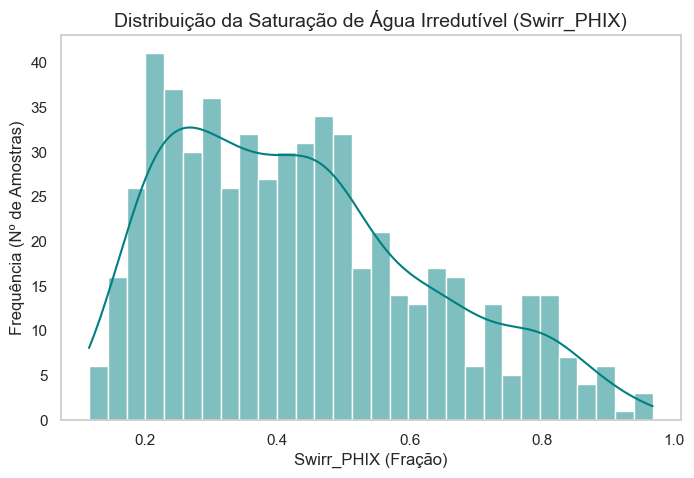

In [75]:
plt.figure(figsize=(8, 5))
sns.histplot(rmn_2['Swirr_PHIX'], bins=30, kde=True, color='teal')
plt.title('Distribuição da Saturação de Água Irredutível (Swirr_PHIX)')
plt.xlabel('Swirr_PHIX (Fração)')
plt.ylabel('Frequência (Nº de Amostras)')
plt.grid(False)
plt.show()

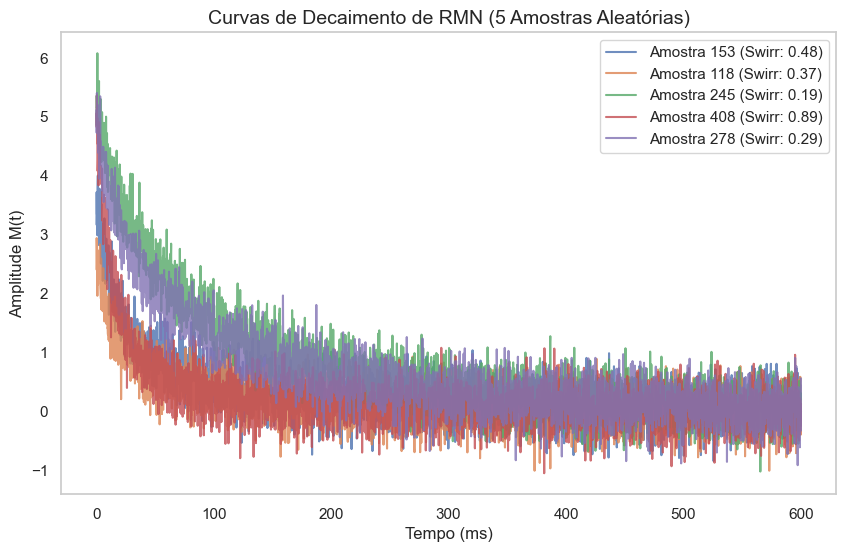

In [77]:
# Separando apenas as colunas dos ecos
echo_cols = [col for col in rmn_2.columns if 'Echo' in col]

# Criando o eixo do tempo (Assumindo que usamos TE = 0.2 ms no script de geração)
TE = 0.2
t = np.arange(1, len(echo_cols) + 1) * TE

plt.figure(figsize=(10, 6))

amostras = rmn_2.sample(5, random_state=42)
for idx, row in amostras.iterrows():
    plt.plot(t, row[echo_cols], label=f'Amostra {idx} (Swirr: {row["Swirr_PHIX"]:.2f})', alpha=0.8)
plt.title('Curvas de Decaimento de RMN (5 Amostras Aleatórias)')
plt.xlabel('Tempo (ms)')
plt.ylabel('Amplitude M(t)')
plt.grid(False)
plt.legend()
plt.show()

C:\Users\aryck\AppData\Local\Temp\ipykernel_29144\724998308.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_por_classe = rmn_2.groupby('Swirr_Class')[echo_cols].mean()


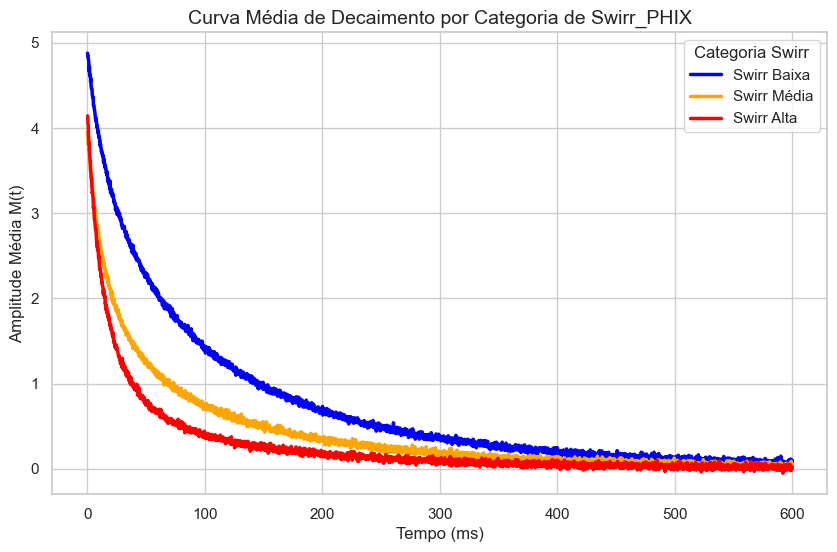

In [78]:
# Criando 3 categorias baseadas nos quantis da Swirr_PHIX
rmn_2['Swirr_Class'] = pd.qcut(rmn_2['Swirr_PHIX'], q=3, labels=['Baixa', 'Média', 'Alta'])

# Calculando a média de cada eco (tempo) por categoria
media_por_classe = rmn_2.groupby('Swirr_Class')[echo_cols].mean()

plt.figure(figsize=(10, 6))
cores = {'Baixa': 'blue', 'Média': 'orange', 'Alta': 'red'}
for classe in ['Baixa', 'Média', 'Alta']:
    plt.plot(t, media_por_classe.loc[classe], label=f'Swirr {classe}', color=cores[classe], linewidth=2.5)
plt.title('Curva Média de Decaimento por Categoria de Swirr_PHIX')
plt.xlabel('Tempo (ms)')
plt.ylabel('Amplitude Média M(t)')
plt.legend(title='Categoria Swirr')
plt.show()

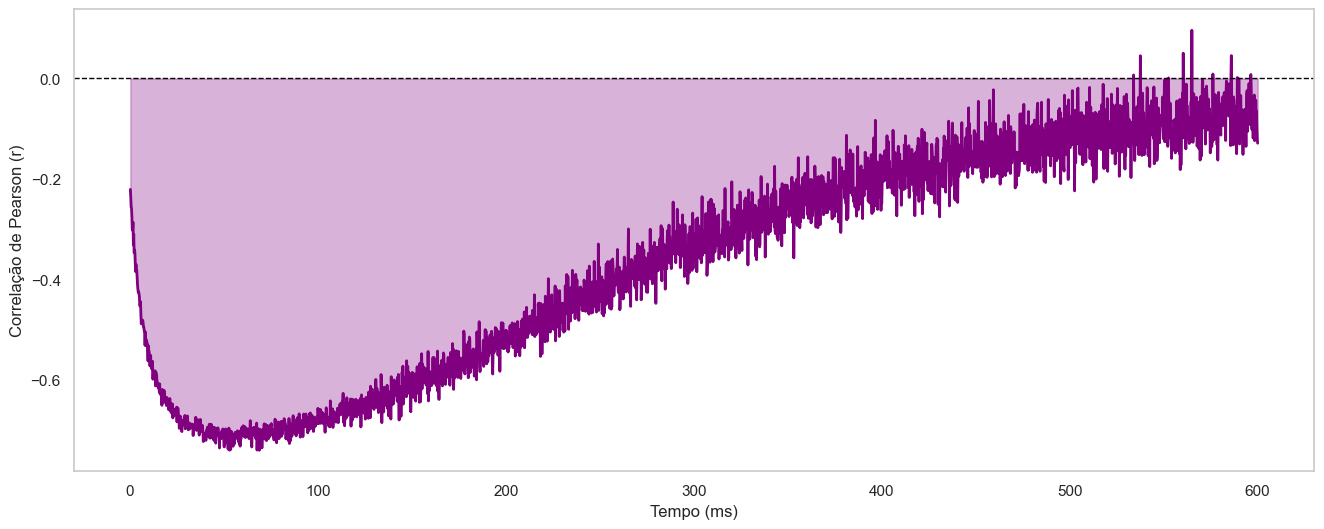

In [89]:
# Calculando a correlação de cada eco com o target Swirr_PHIX
correlacoes = rmn_2[echo_cols].apply(lambda col: col.corr(rmn_2['Swirr_PHIX']))

plt.figure(figsize=(16, 6))
plt.plot(t, correlacoes, color='purple', linewidth=2)
# plt.title('Correlação entre a Amplitude no Tempo (Eco) e a Swirr_PHIX')
plt.xlabel('Tempo (ms)')
plt.ylabel('Correlação de Pearson (r)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.fill_between(t, correlacoes, 0, alpha=0.3, color='purple')
plt.grid(False)
plt.show()

### Verificando relação dos sinais normalizados

In [80]:
echo_cols = [col for col in rmn_2.columns if 'Echo' in col]
df_ecos = rmn_2[echo_cols]

df_norm = df_ecos.div(df_ecos.max(axis=1), axis=0)


In [81]:
# SUAVIZAÇÃO (Filtro Savitzky-Golay)
suavizado_array = savgol_filter(df_norm, window_length=31, polyorder=3, axis=1)

# Reconstruindo o DataFrame com os dados suavizados e adicionando a Swirr
df_smooth = pd.DataFrame(suavizado_array, columns=echo_cols, index=df_norm.index)
df_smooth['Swirr_PHIX'] = rmn_2['Swirr_PHIX']

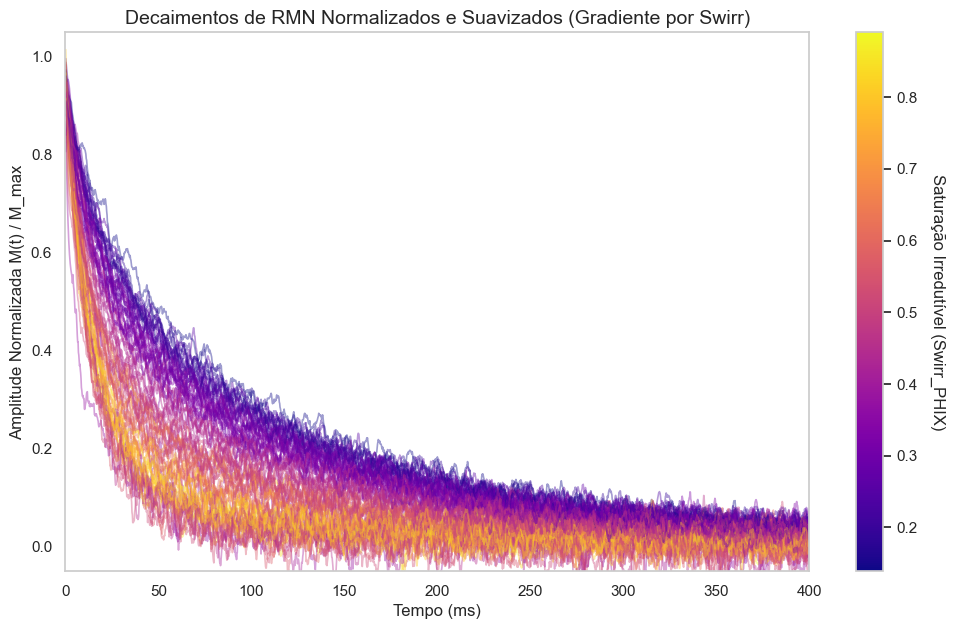

In [83]:
# PREPARAÇÃO PARA O GRÁFICO
TE = 0.2
t = np.arange(1, len(echo_cols) + 1) * TE

# Vamos usar uma amostra de ~200 curvas para o gráfico não ficar pesado/borrado demais
amostra_plot = df_smooth.sample(n=min(90, len(df_smooth)), random_state=42)

# Configurando o mapeamento de cores (Gradiente)
# Usaremos o colormap 'plasma' (vai do roxo escuro pro amarelo)
cmap = plt.get_cmap('plasma') 
norm = mcolors.Normalize(vmin=amostra_plot['Swirr_PHIX'].min(), 
                         vmax=amostra_plot['Swirr_PHIX'].max())

# PLOTAGEM
plt.figure(figsize=(12, 7))

for idx, row in amostra_plot.iterrows():
    # Define a cor desta curva baseada no valor de Swirr
    cor = cmap(norm(row['Swirr_PHIX']))
    
    # Plotando com um alpha (transparência) para visualizar sobreposições
    plt.plot(t, row[echo_cols], color=cor, alpha=0.4, linewidth=1.2)

# Configuração da barra de cores lateral
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Saturação Irredutível (Swirr_PHIX)', rotation=270, labelpad=20, fontsize=12)

# Ajustes visuais
plt.title('Decaimentos de RMN Normalizados e Suavizados (Gradiente por Swirr)', fontsize=14)
plt.xlabel('Tempo (ms)', fontsize=12)
plt.ylabel('Amplitude Normalizada M(t) / M_max', fontsize=12)
plt.xlim(0, 400) # Limitando o eixo X se quiser ver os primeiros 100ms (ajuste conforme necessário)
plt.grid(False)
plt.ylim(-0.05, 1.05)
plt.show()